In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as ply
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df=pd.read_csv('kidney_disease.csv')
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [6]:
obj_col=[]
num_col=[]
for i in df.columns:
    if df[i].dtype=='object':
        obj_col.append(i)
    else:
        num_col.append(i)

In [7]:
print(obj_col,num_col,sep='\n')

['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [8]:
from sklearn.impute import KNNImputer
imputer=KNNImputer()
df_num=pd.DataFrame(imputer.fit_transform(df[num_col]),columns=num_col)
df_num

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,124.6,3.84,15.4
1,1.0,7.0,50.0,1.020,4.0,0.0,245.2,18.0,0.8,134.2,3.60,11.3
2,2.0,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,133.0,4.54,9.6
3,3.0,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.50,11.2
4,4.0,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,132.2,3.68,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.90,15.7
396,396.0,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.50,16.5
397,397.0,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.40,15.8
398,398.0,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.90,14.2


In [9]:
from sklearn.impute import SimpleImputer
imputer_cat=SimpleImputer(strategy='most_frequent')
df_col=pd.DataFrame(imputer_cat.fit_transform(df[obj_col]),columns=obj_col)
df_col

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,normal,normal,notpresent,notpresent,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,normal,normal,notpresent,notpresent,38,6000,5.2,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,31,7500,5.2,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,47,6700,4.9,no,no,no,good,no,no,notckd
396,normal,normal,notpresent,notpresent,54,7800,6.2,no,no,no,good,no,no,notckd
397,normal,normal,notpresent,notpresent,49,6600,5.4,no,no,no,good,no,no,notckd
398,normal,normal,notpresent,notpresent,51,7200,5.9,no,no,no,good,no,no,notckd


In [10]:
df_2=pd.concat([df_col,df_num],axis=1)
df_2

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,...,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,normal,normal,notpresent,notpresent,44,7800,5.2,yes,yes,no,...,80.0,1.020,1.0,0.0,121.0,36.0,1.2,124.6,3.84,15.4
1,normal,normal,notpresent,notpresent,38,6000,5.2,no,no,no,...,50.0,1.020,4.0,0.0,245.2,18.0,0.8,134.2,3.60,11.3
2,normal,normal,notpresent,notpresent,31,7500,5.2,no,yes,no,...,80.0,1.010,2.0,3.0,423.0,53.0,1.8,133.0,4.54,9.6
3,normal,abnormal,present,notpresent,32,6700,3.9,yes,no,no,...,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.50,11.2
4,normal,normal,notpresent,notpresent,35,7300,4.6,no,no,no,...,80.0,1.010,2.0,0.0,106.0,26.0,1.4,132.2,3.68,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,47,6700,4.9,no,no,no,...,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.90,15.7
396,normal,normal,notpresent,notpresent,54,7800,6.2,no,no,no,...,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.50,16.5
397,normal,normal,notpresent,notpresent,49,6600,5.4,no,no,no,...,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.40,15.8
398,normal,normal,notpresent,notpresent,51,7200,5.9,no,no,no,...,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.90,14.2


In [11]:
df_2.isna().sum()

rbc               0
pc                0
pcc               0
ba                0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
id                0
age               0
bp                0
sg                0
al                0
su                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
dtype: int64

In [12]:
for i in df_2.columns:
    print('-----------------------------------',i,'---------------------------')
    print(df_2[i].unique())
    print()

----------------------------------- rbc ---------------------------
['normal' 'abnormal']

----------------------------------- pc ---------------------------
['normal' 'abnormal']

----------------------------------- pcc ---------------------------
['notpresent' 'present']

----------------------------------- ba ---------------------------
['notpresent' 'present']

----------------------------------- pcv ---------------------------
['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' '41' '16' '24' '37'
 '30' '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46'
 '23' '19' '25' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']

----------------------------------- wc ---------------------------
['7800' '6000' '7500' '6700' '7300' '9800' '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300' '7200'
 '7700' '14600' '6300' '\t6200' '7100' '11800' '

### here check the data multiple errors are there in data like numbers in string, symbols , spaces in classes etc.........

In [13]:
df_2['pcv']=df_2['pcv'].apply(lambda x: '43' if x=='\t43' else x)
df_2['pcv']=df_2['pcv'].apply(lambda x: '41' if x=='\t?' else x)  # df_2['pcv'].mode()
df_2['wc']=df_2['wc'].apply(lambda x: '6200' if x=='\t6200' else x)
df_2['wc']=df_2['wc'].apply(lambda x: '8400' if x=='\t8400' else x)
df_2['wc']=df_2['wc'].apply(lambda x: '9800' if x=='\t?' else x)
df_2['rc']=df_2['rc'].apply(lambda x: '5.2' if x=='\t?' else x)
df_2['dm']=df_2['dm'].apply(lambda x: 'no' if x=='\tno' else x)
df_2['dm']=df_2['dm'].apply(lambda x: 'yes' if x=='\tyes' else x)
df_2['dm']=df_2['dm'].apply(lambda x: 'yes' if x==' yes' else x)
df_2['cad']=df_2['cad'].apply(lambda x: 'no' if x=='\tno' else x)
df_2['classification']=df_2['classification'].apply(lambda x: 'ckd' if x=='ckd\t' else x)

In [14]:
df_2['pcv'].mode()[0]

'41'

In [15]:
df_2['wc'].mode()[0]

'9800'

In [16]:
df_2['rc'].mode()[0]

'5.2'

In [17]:
for i in df_2.columns:
    print('-----------------------------------',i,'---------------------------')
    print(df_2[i].unique())
    print()

----------------------------------- rbc ---------------------------
['normal' 'abnormal']

----------------------------------- pc ---------------------------
['normal' 'abnormal']

----------------------------------- pcc ---------------------------
['notpresent' 'present']

----------------------------------- ba ---------------------------
['notpresent' 'present']

----------------------------------- pcv ---------------------------
['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' '41' '16' '24' '37'
 '30' '34' '40' '45' '27' '48' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '26' '15' '21' '43' '20' '47' '9' '49' '50' '53' '51' '54']

----------------------------------- wc ---------------------------
['7800' '6000' '7500' '6700' '7300' '9800' '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300' '7200'
 '7700' '14600' '6300' '7100' '11800' '9400' '5500' '5800' '13

In [18]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rbc             400 non-null    object 
 1   pc              400 non-null    object 
 2   pcc             400 non-null    object 
 3   ba              400 non-null    object 
 4   pcv             400 non-null    object 
 5   wc              400 non-null    object 
 6   rc              400 non-null    object 
 7   htn             400 non-null    object 
 8   dm              400 non-null    object 
 9   cad             400 non-null    object 
 10  appet           400 non-null    object 
 11  pe              400 non-null    object 
 12  ane             400 non-null    object 
 13  classification  400 non-null    object 
 14  id              400 non-null    float64
 15  age             400 non-null    float64
 16  bp              400 non-null    float64
 17  sg              400 non-null    flo

In [19]:
cols=['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane','classification']
for i in cols:
    df_2[i]=df_2[i].astype('category')
    df_2[i]=df_2[i].cat.codes

In [20]:
cols=['pcv','wc','rc']
for i in cols:
    df_2[i]=df_2[i].astype('float64')

In [21]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rbc             400 non-null    int8   
 1   pc              400 non-null    int8   
 2   pcc             400 non-null    int8   
 3   ba              400 non-null    int8   
 4   pcv             400 non-null    float64
 5   wc              400 non-null    float64
 6   rc              400 non-null    float64
 7   htn             400 non-null    int8   
 8   dm              400 non-null    int8   
 9   cad             400 non-null    int8   
 10  appet           400 non-null    int8   
 11  pe              400 non-null    int8   
 12  ane             400 non-null    int8   
 13  classification  400 non-null    int8   
 14  id              400 non-null    float64
 15  age             400 non-null    float64
 16  bp              400 non-null    float64
 17  sg              400 non-null    flo

In [23]:
df_2['classification'].value_counts(normalize=True)

classification
0    0.625
1    0.375
Name: proportion, dtype: float64

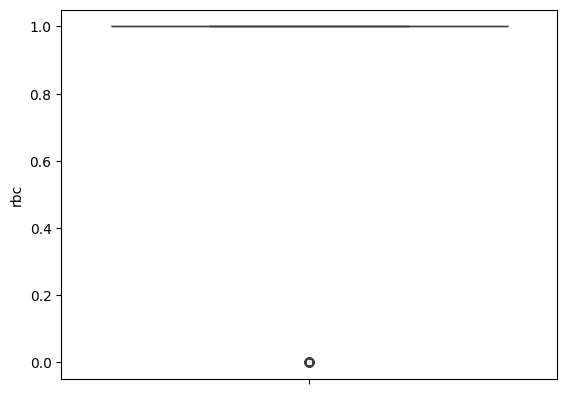

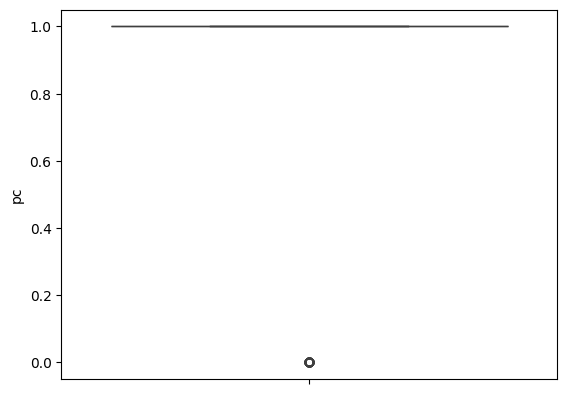

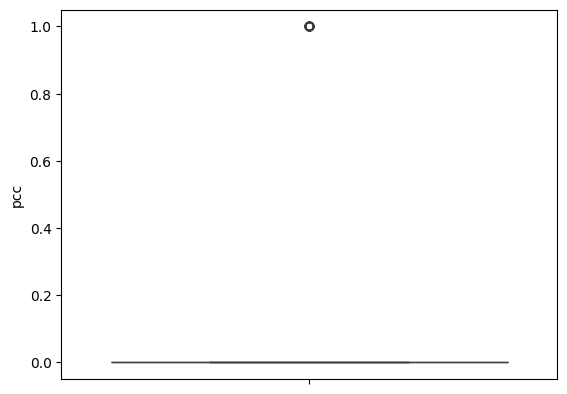

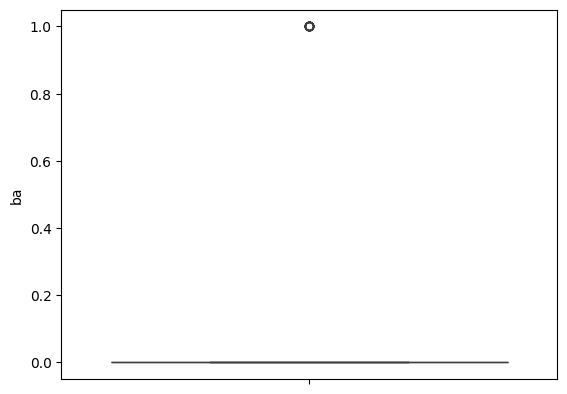

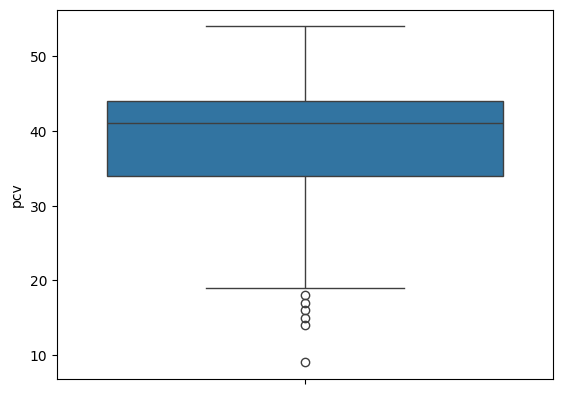

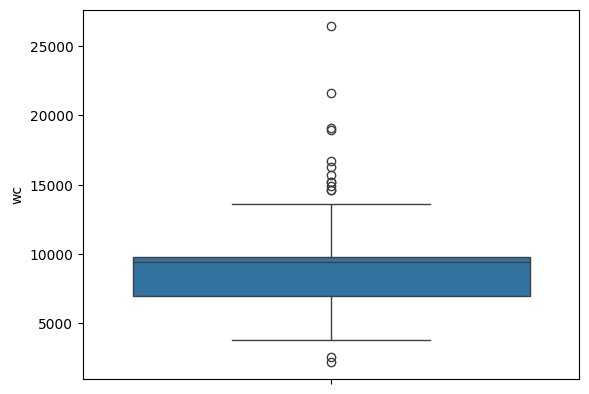

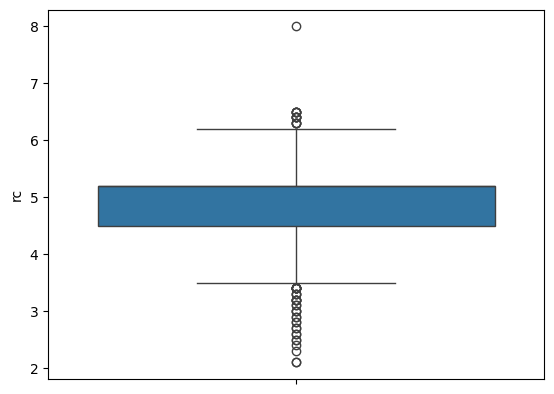

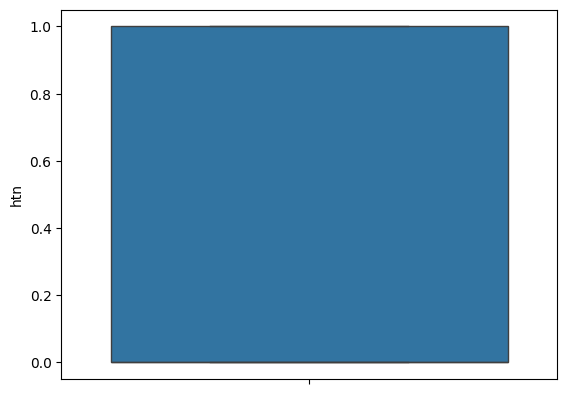

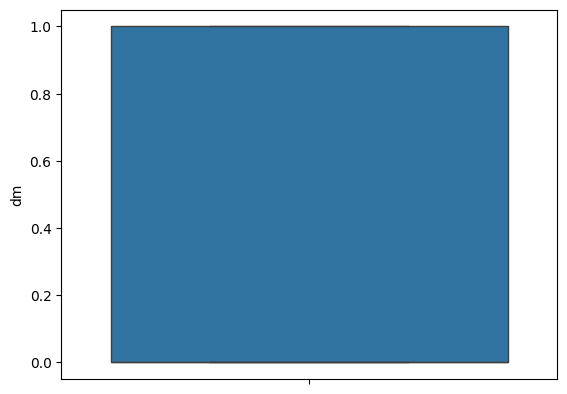

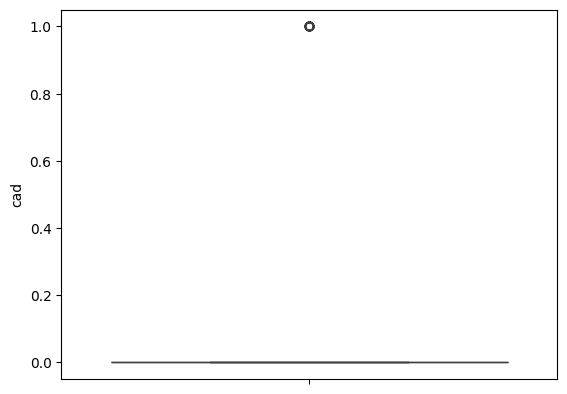

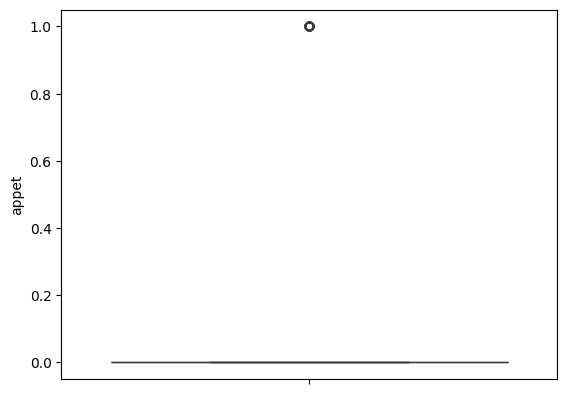

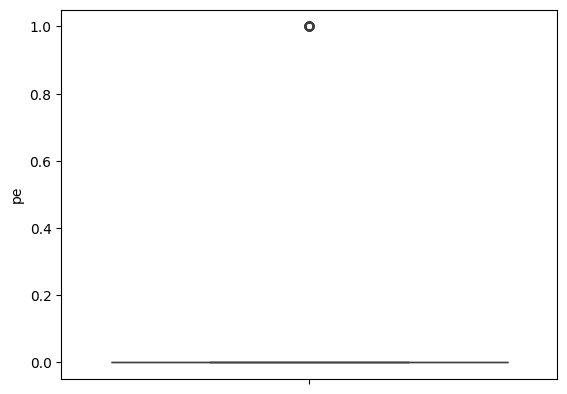

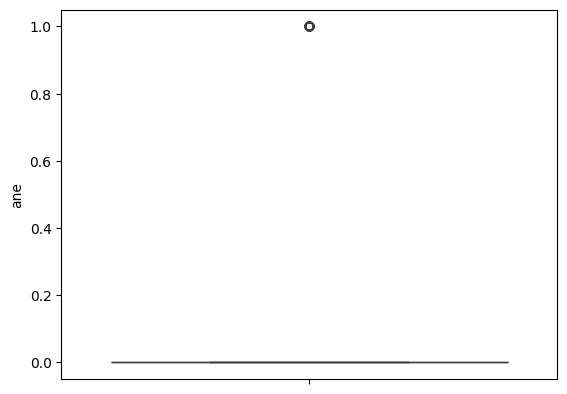

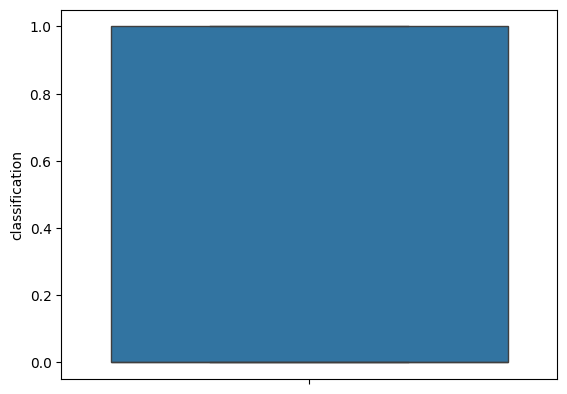

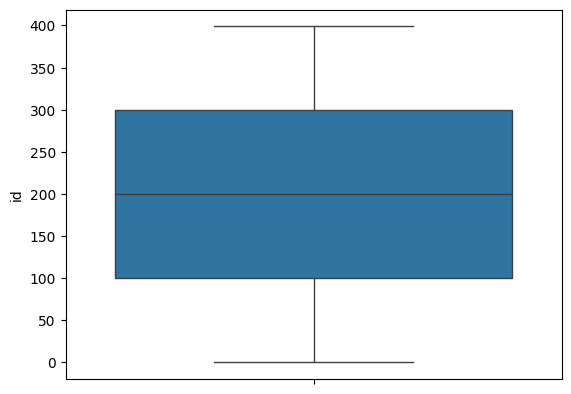

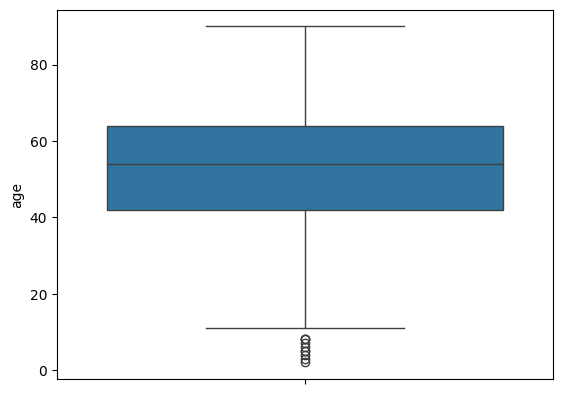

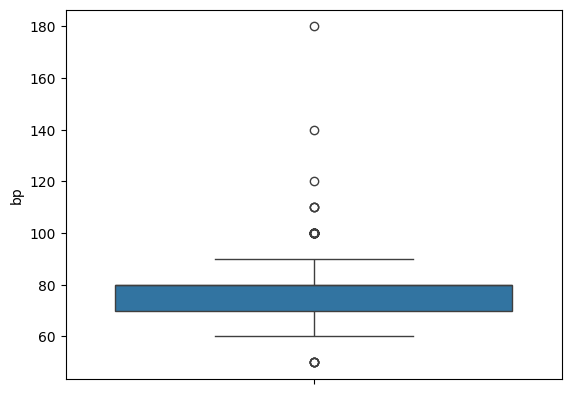

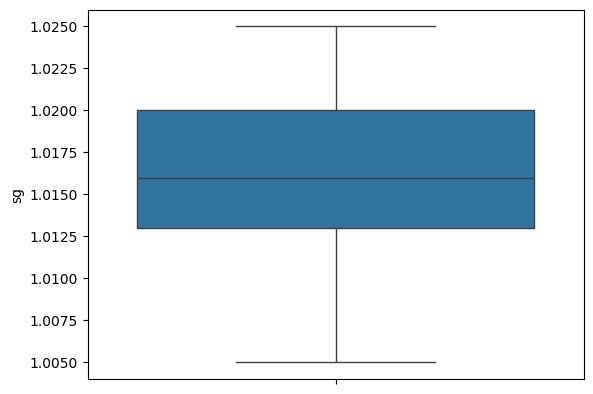

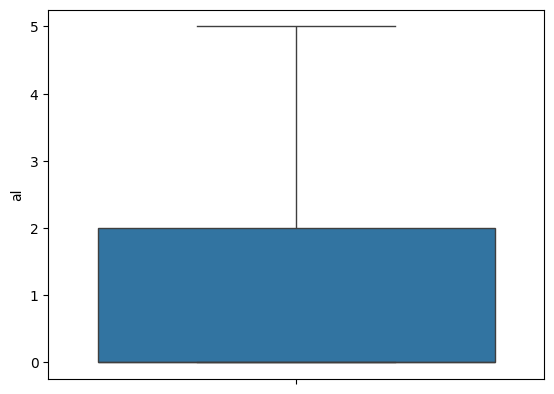

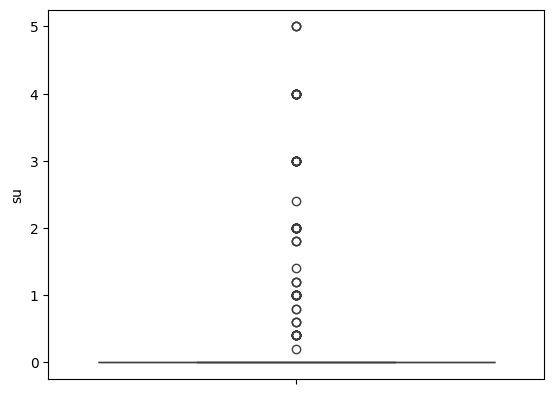

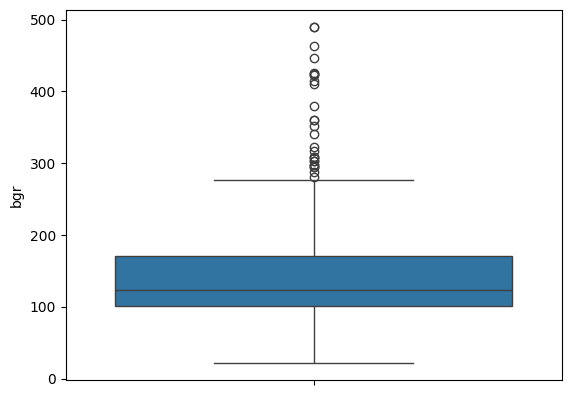

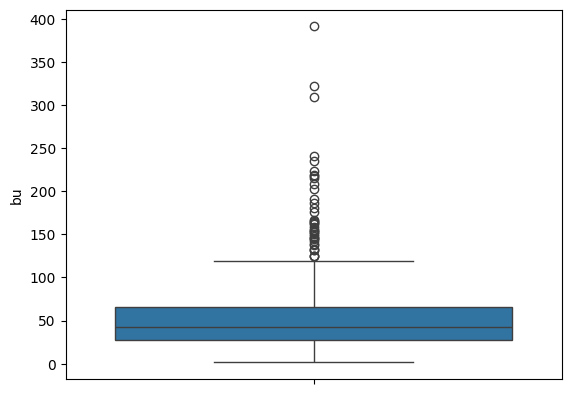

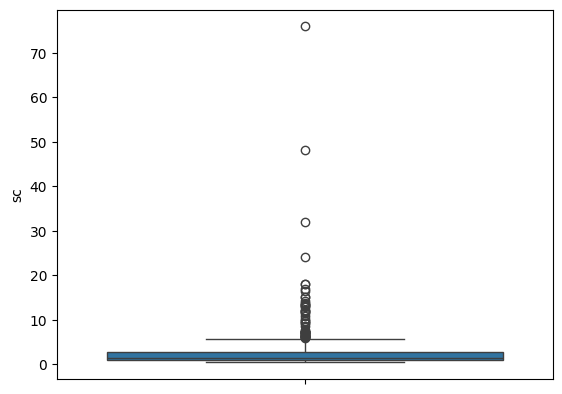

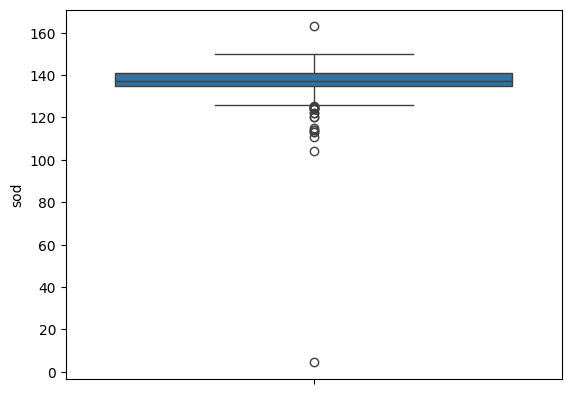

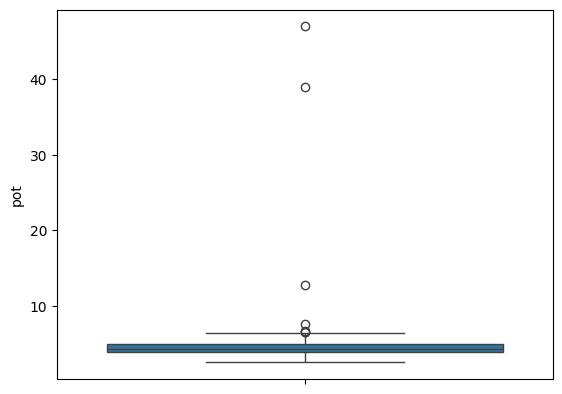

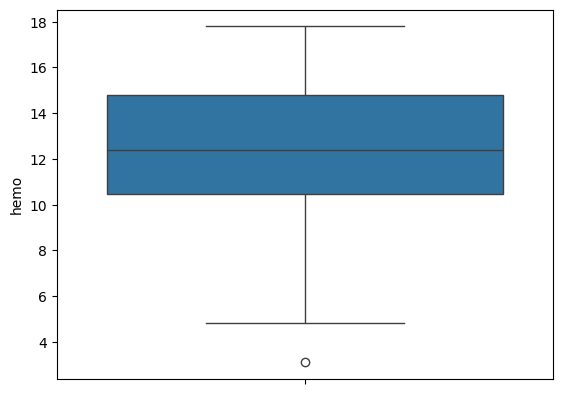

In [28]:
def plots(col):
    sns.boxplot(df_2[col])
    ply.show()
for i in list(df_2.select_dtypes(exclude='object')):
    plots(i)

In [35]:
cols=['pcv','wc','rc','age','bp','bgr','bu','sc','sod','pot']

In [37]:
for i in cols:
    Q1=df_2[i].quantile(0.25)
    Q3=df_2[i].quantile(0.75)
    IQR=Q3-Q1
    upper_limit= Q3 + IQR * 1.5
    lower_limit= Q1 - IQR * 1.5
    df_2[i]=np.where(df_2[i]>upper_limit,upper_limit,np.where(df_2[i]<lower_limit,lower_limit,df_2[i]))

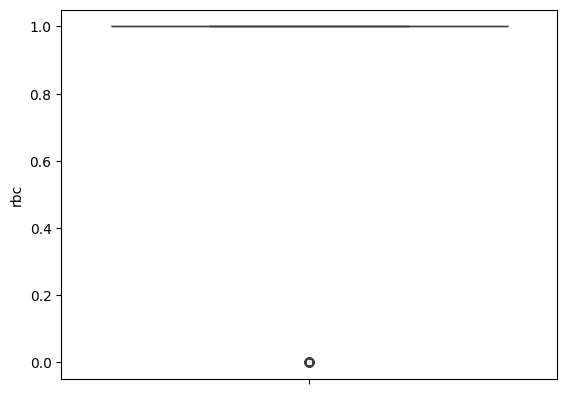

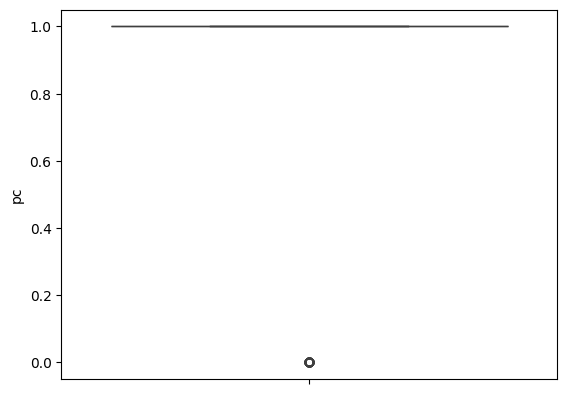

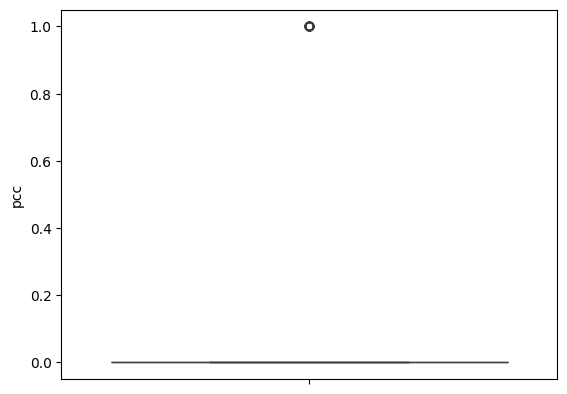

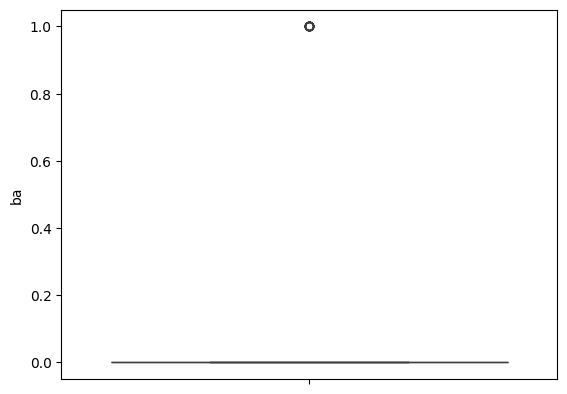

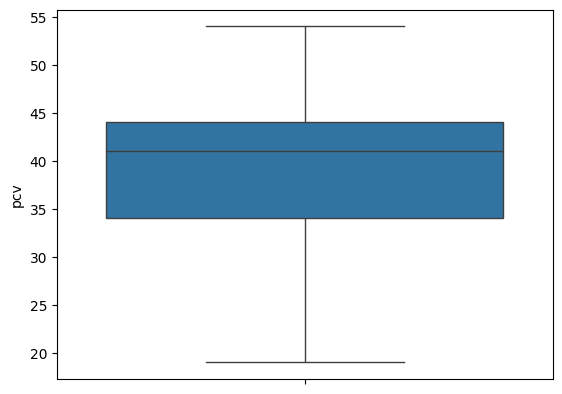

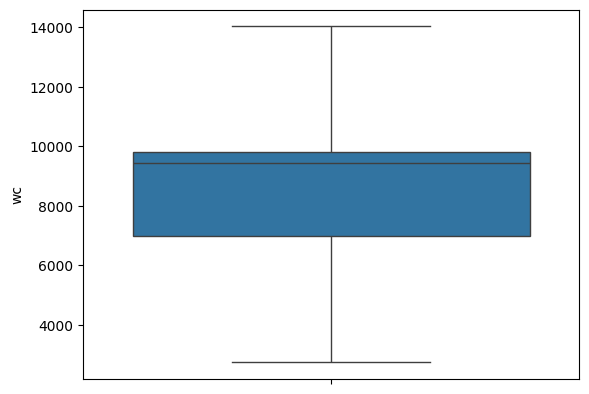

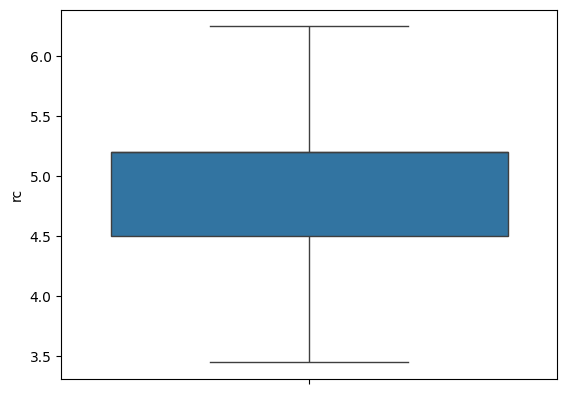

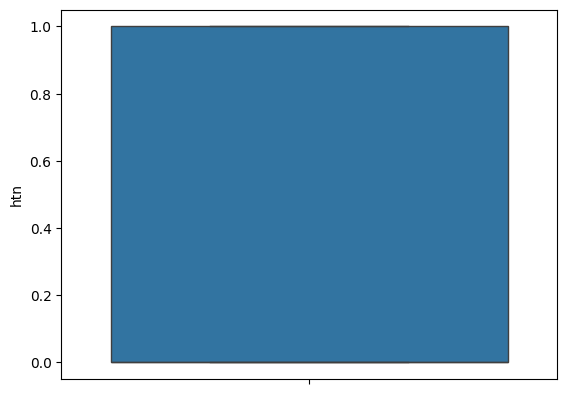

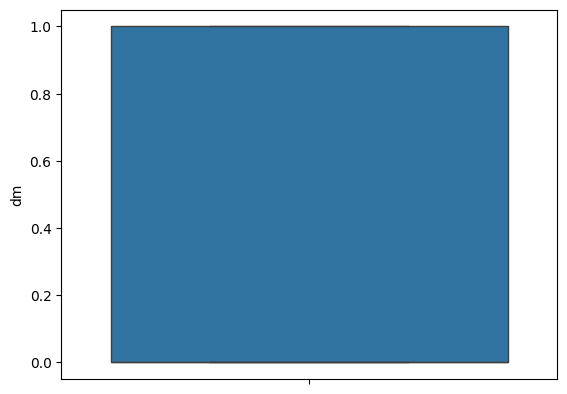

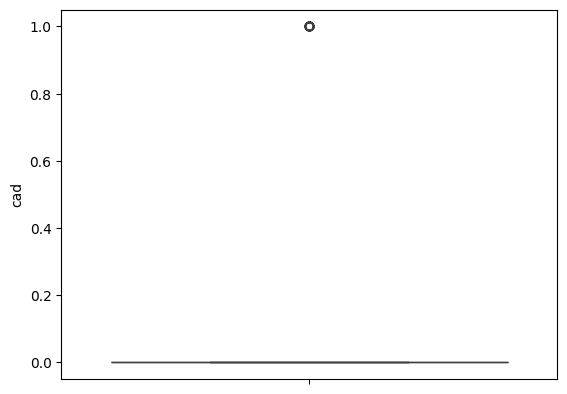

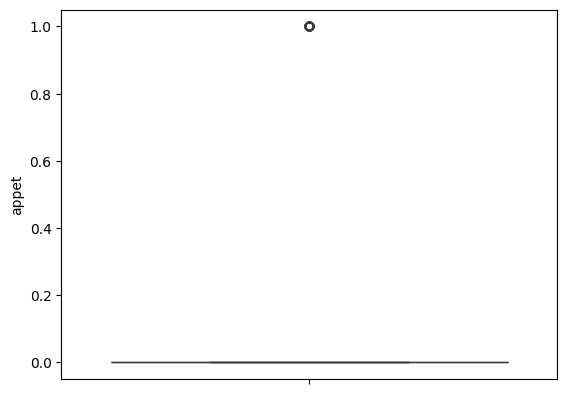

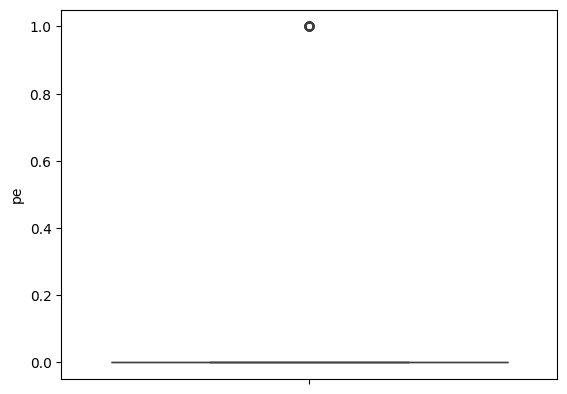

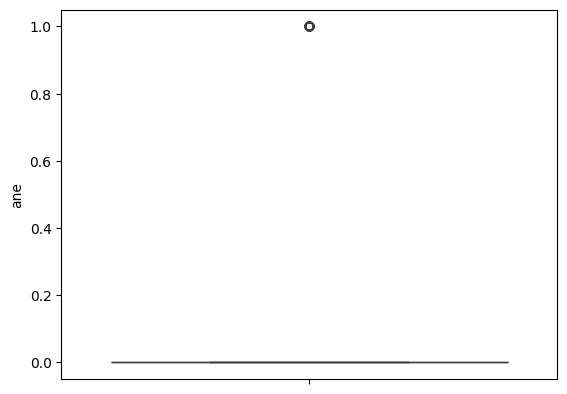

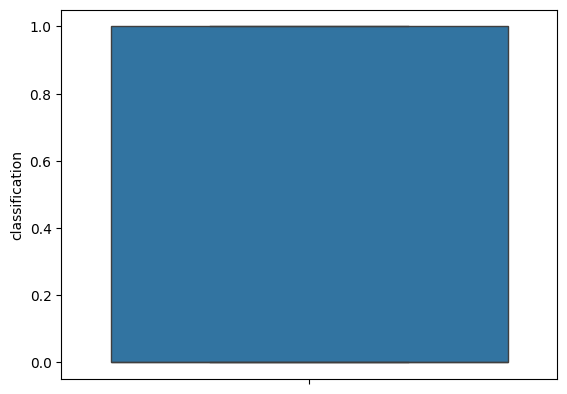

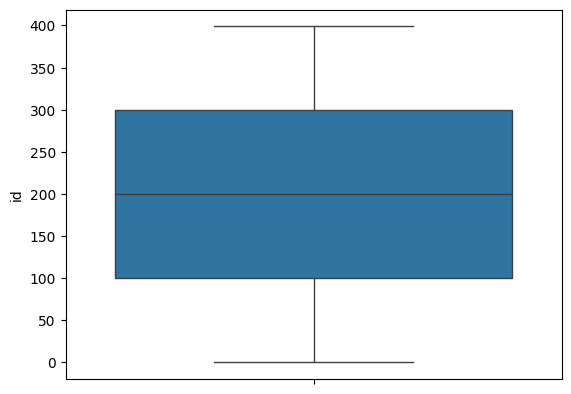

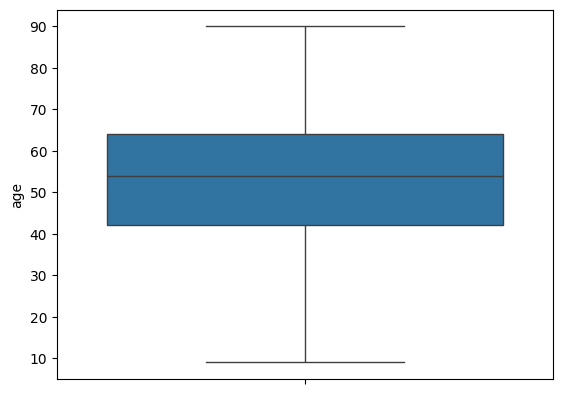

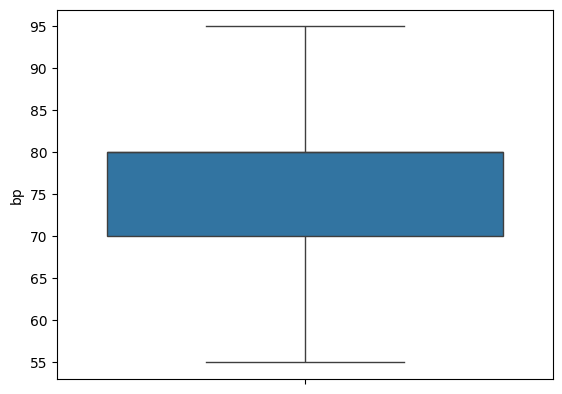

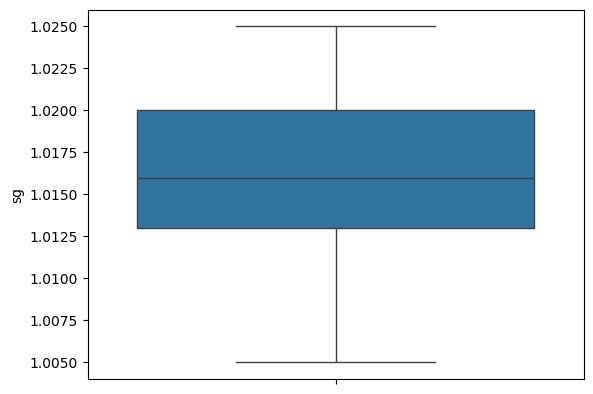

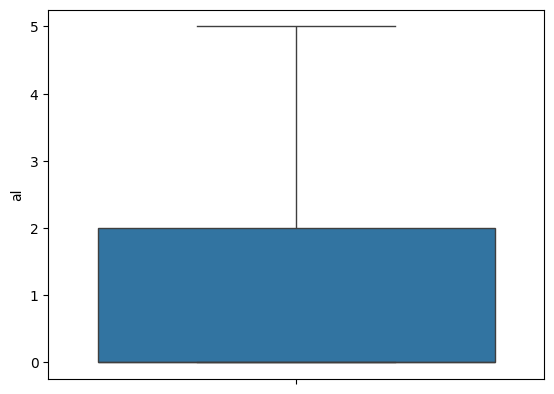

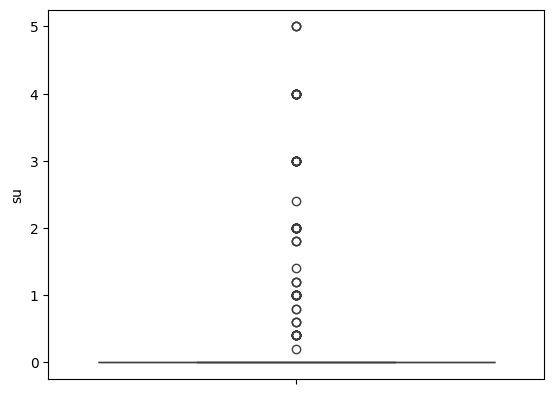

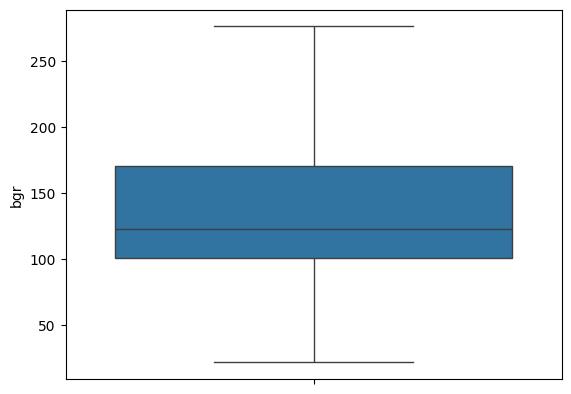

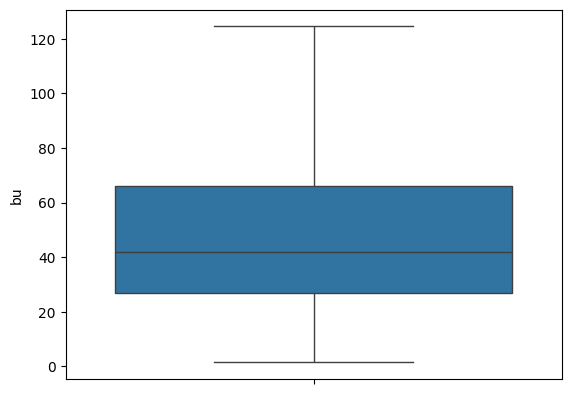

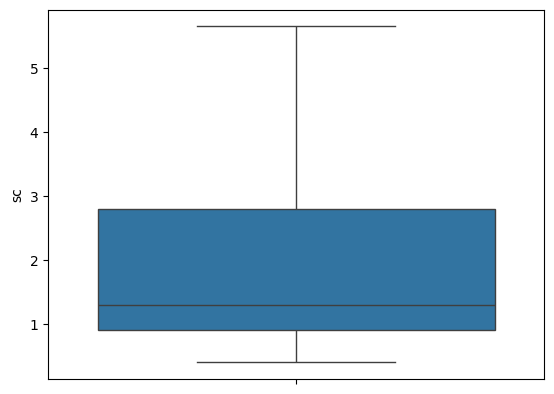

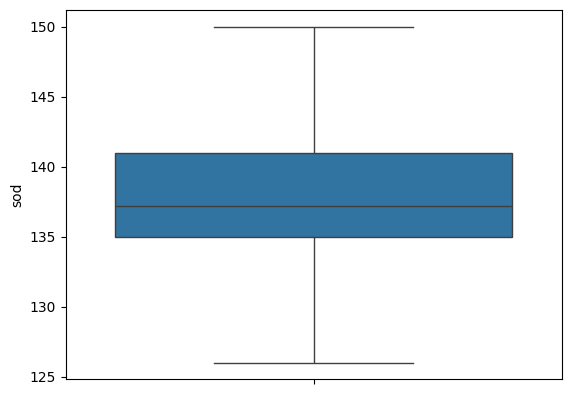

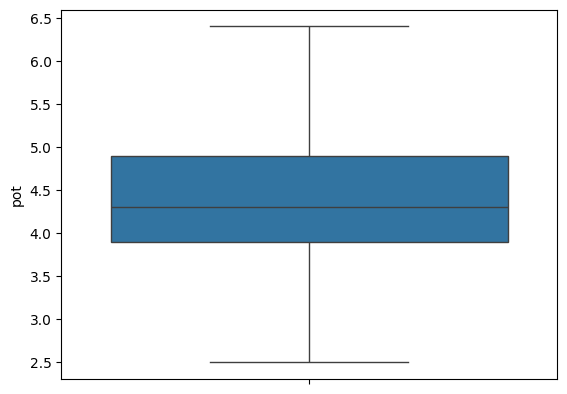

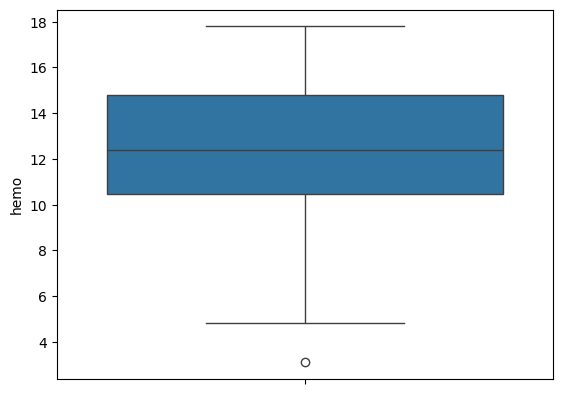

In [38]:
def plots(col):
    sns.boxplot(df_2[col])
    ply.show()
for i in list(df_2.select_dtypes(exclude='object')):
    plots(i)

In [41]:
df_2.drop('id',inplace=True,axis=1)

In [43]:
df_2

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,...,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,1,1,0,0,44.0,7800.0,5.2,1,1,0,...,80.0,1.020,1.0,0.0,121.000,36.0,1.2,126.0,3.84,15.4
1,1,1,0,0,38.0,6000.0,5.2,0,0,0,...,55.0,1.020,4.0,0.0,245.200,18.0,0.8,134.2,3.60,11.3
2,1,1,0,0,31.0,7500.0,5.2,0,1,0,...,80.0,1.010,2.0,3.0,276.375,53.0,1.8,133.0,4.54,9.6
3,1,0,1,0,32.0,6700.0,3.9,1,0,0,...,70.0,1.005,4.0,0.0,117.000,56.0,3.8,126.0,2.50,11.2
4,1,1,0,0,35.0,7300.0,4.6,0,0,0,...,80.0,1.010,2.0,0.0,106.000,26.0,1.4,132.2,3.68,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,1,1,0,0,47.0,6700.0,4.9,0,0,0,...,80.0,1.020,0.0,0.0,140.000,49.0,0.5,150.0,4.90,15.7
396,1,1,0,0,54.0,7800.0,6.2,0,0,0,...,70.0,1.025,0.0,0.0,75.000,31.0,1.2,141.0,3.50,16.5
397,1,1,0,0,49.0,6600.0,5.4,0,0,0,...,80.0,1.020,0.0,0.0,100.000,26.0,0.6,137.0,4.40,15.8
398,1,1,0,0,51.0,7200.0,5.9,0,0,0,...,60.0,1.025,0.0,0.0,114.000,50.0,1.0,135.0,4.90,14.2


In [49]:
X=df_2.drop('classification',axis=1)
Y=df_2['classification']

In [50]:
Y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: classification, Length: 400, dtype: int8

In [51]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=pd.DataFrame(scaler.fit_transform(X),columns=X.columns)
X_scaled

,rbc,pc,pcc,ba,pcv,wc,rc,htn,dm,cad,...,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.36489,0.484322,-0.342518,-0.241249,0.584672,-0.394222,0.396813,1.311903,1.385535,-0.304789,...,0.403231,0.517093,-0.051193,-0.436599,-0.386323,-0.483547,-0.552989,-2.095315,-0.762875,1.061403
1,0.36489,0.484322,-0.342518,-0.241249,-0.165308,-1.204904,0.396813,-0.762252,-0.721743,-0.304789,...,-1.869771,0.517093,2.241014,-0.436599,1.701707,-1.029577,-0.788310,-0.629935,-1.107547,-0.411919
2,0.36489,0.484322,-0.342518,-0.241249,-1.040284,-0.529336,0.396813,-0.762252,1.385535,-0.304789,...,0.403231,-1.298862,0.712876,2.423222,2.225816,0.032147,-0.200008,-0.844381,0.242420,-1.022809
3,0.36489,-2.064742,2.919556,-0.241249,-0.915288,-0.889639,-1.324862,1.311903,-0.721743,-0.304789,...,-0.505970,-2.206839,2.241014,-0.436599,-0.453571,0.123152,0.976596,-2.095315,-2.687295,-0.447854
4,0.36489,0.484322,-0.342518,-0.241249,-0.540298,-0.619412,-0.397806,-0.762252,-0.721743,-0.304789,...,0.403231,-1.298862,0.712876,-0.436599,-0.638501,-0.786897,-0.435329,-0.987345,-0.992656,-0.304115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,0.36489,0.484322,-0.342518,-0.241249,0.959661,-0.889639,-0.000497,-0.762252,-0.721743,-0.304789,...,0.403231,0.517093,-0.815262,-0.436599,-0.066899,-0.089192,-0.964800,2.193603,0.759428,1.169207
396,0.36489,0.484322,-0.342518,-0.241249,1.834637,-0.394222,1.721179,-0.762252,-0.721743,-0.304789,...,-0.505970,1.425070,-0.815262,-0.436599,-1.159668,-0.635222,-0.552989,0.585259,-1.251160,1.456685
397,0.36489,0.484322,-0.342518,-0.241249,1.209654,-0.934677,0.661686,-0.762252,-0.721743,-0.304789,...,0.403231,0.517093,-0.815262,-0.436599,-0.739372,-0.786897,-0.905970,-0.129561,0.041361,1.205142
398,0.36489,0.484322,-0.342518,-0.241249,1.459648,-0.664450,1.323869,-0.762252,-0.721743,-0.304789,...,-1.415171,1.425070,-0.815262,-0.436599,-0.504006,-0.058857,-0.670649,-0.486971,0.759428,0.630187


<Axes: >

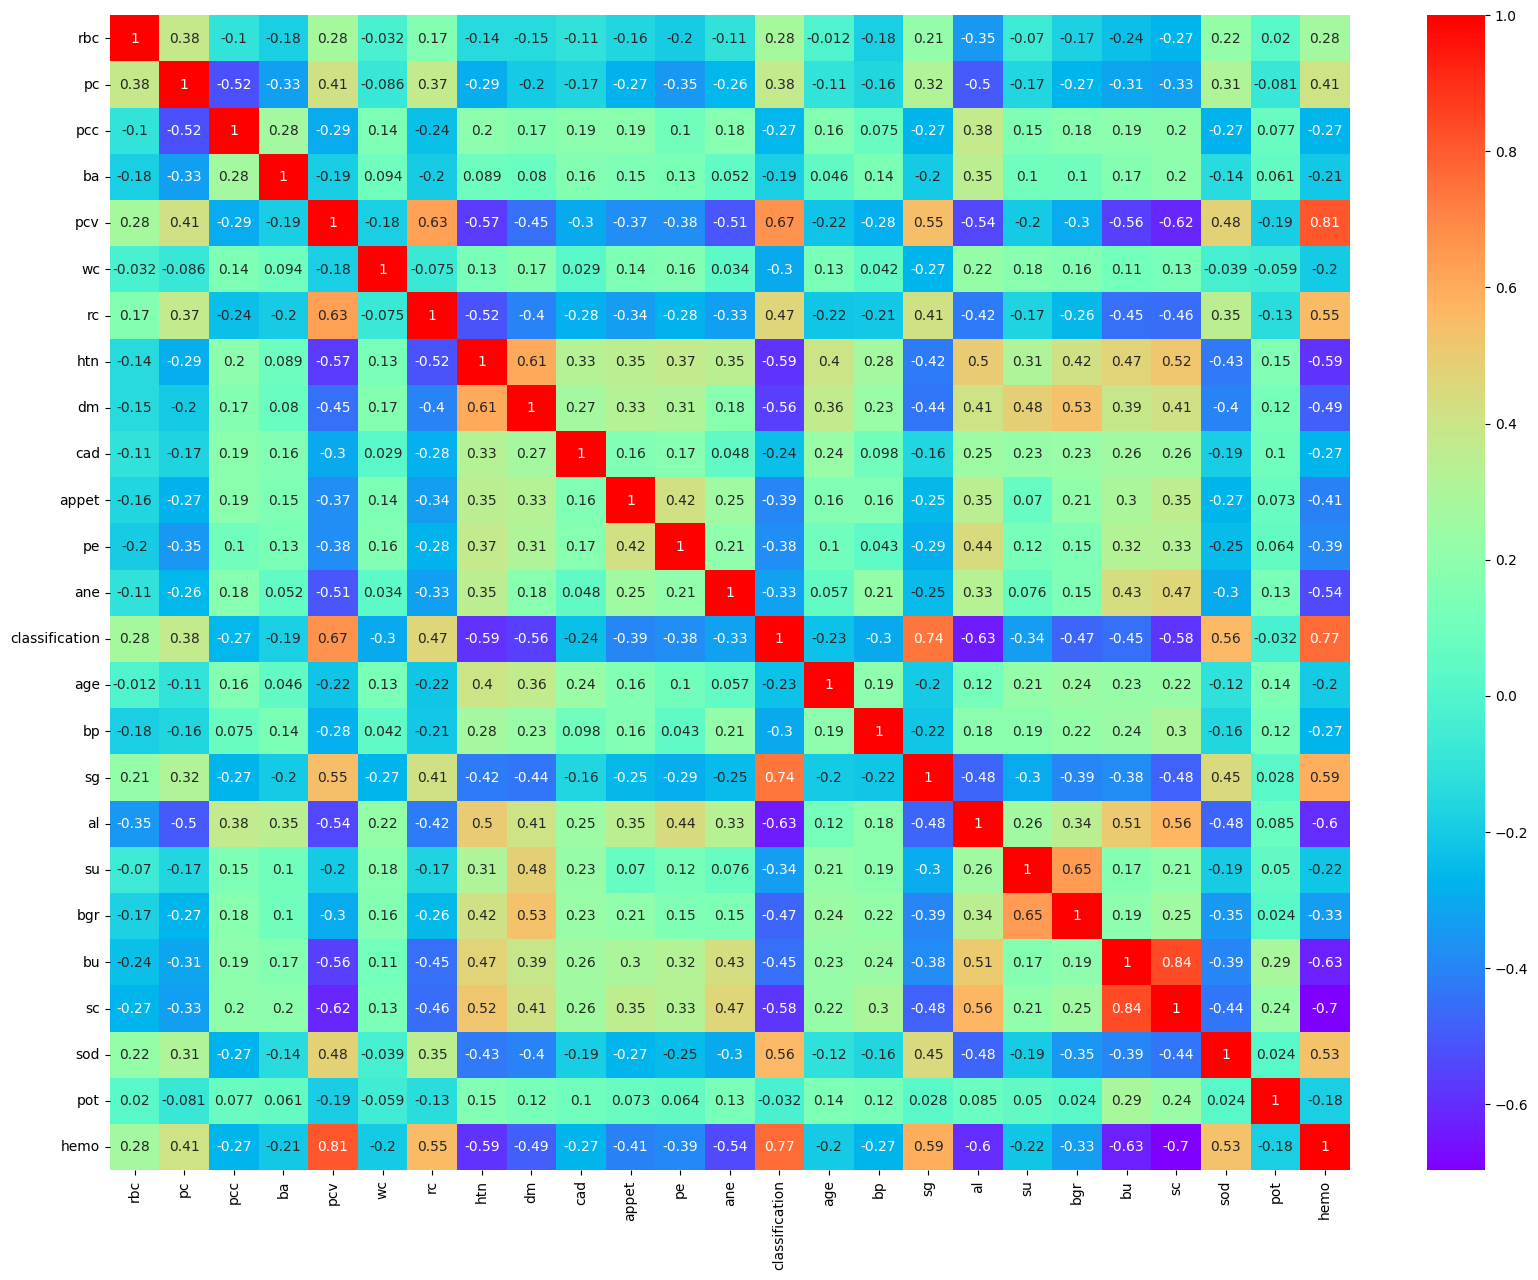

In [58]:
ply.figure(figsize=(20,15))
sns.heatmap(df_2.corr(),annot=True,cmap='rainbow')

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_scaled,Y,random_state=1,test_size=0.2,stratify=Y)

# Building Classification model

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB,GaussianNB

from sklearn.metrics import classification_report,accuracy_score

In [84]:
models=[]
accuracy=[]


# Logistic Regression
logit=LogisticRegression()
logit.fit(X_train,y_train)
y_pred_log=logit.predict(X_test)
acc_log=accuracy_score(y_test,y_pred_log)

# Decision Tree
dtree=DecisionTreeClassifier()
dtree.fit(X_train,y_train)
y_pred_dtree=dtree.predict(X_test)
acc_dtree=accuracy_score(y_test,y_pred_dtree)

# RandomForest
rfc=RandomForestClassifier()
rfc.fit(X_train,y_train)
y_pred_rfc=rfc.predict(X_test)
acc_rfc=accuracy_score(y_test,y_pred_rfc)

# GradientBoostingClassifier
gb=GradientBoostingClassifier()
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)
acc_gb=accuracy_score(y_test,y_pred_gb)

# AdaBoostClassifier
ada=AdaBoostClassifier()
ada.fit(X_train,y_train)
y_pred_ada=ada.predict(X_test)
acc_ada=accuracy_score(y_test,y_pred_ada)

# BaggingClassifier
bag=BaggingClassifier()
bag.fit(X_train,y_train)
y_pred_bag=bag.predict(X_test)
acc_bag=accuracy_score(y_test,y_pred_bag)

# ExtraTreesClassifier
extra=ExtraTreesClassifier()
extra.fit(X_train,y_train)
y_pred_extra=extra.predict(X_test)
acc_extra=accuracy_score(y_test,y_pred_extra)

# KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)
acc_knn=accuracy_score(y_test,y_pred_knn)

# XGBClassifier
xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred_xgb=xgb.predict(X_test)
acc_xgb=accuracy_score(y_test,y_pred_xgb)

# SVC
svc=SVC()
svc.fit(X_train,y_train)
y_pred_svc=svc.predict(X_test)
acc_svc=accuracy_score(y_test,y_pred_svc)

# BernoulliNB
bnb=BernoulliNB()
bnb.fit(X_train,y_train)
y_pred_bnb=bnb.predict(X_test)
acc_bnb=accuracy_score(y_test,y_pred_bnb)

# GaussianNB
gnb=GaussianNB()
gnb.fit(X_train,y_train)
y_pred_gnb=gnb.predict(X_test)
acc_gnb=accuracy_score(y_test,y_pred_gnb)

accuracy=[acc_log,acc_dtree,acc_rfc,acc_gb,acc_ada,acc_bag,acc_extra,acc_knn,acc_xgb,acc_svc,acc_bnb,acc_gnb]
models=['Logistic Regression','Decision Tree','RandomForest','GradientBoostingClassifier','AdaBoostClassifier','BaggingClassifier',
        'ExtraTreesClassifier','KNeighborsClassifier','XGBClassifier','SVC','BernoulliNB','GaussianNB']


In [85]:
report_df=pd.DataFrame({'Accuracy':accuracy,'models':models})

,Accuracy,models
0,1.0000,Logistic Regression
1,0.9625,Decision Tree
2,1.0000,RandomForest
3,0.9625,GradientBoostingClassifier
4,1.0000,AdaBoostClassifier
5,1.0000,BaggingClassifier
6,1.0000,ExtraTreesClassifier
7,0.9875,KNeighborsClassifier
8,1.0000,XGBClassifier
9,1.0000,SVC


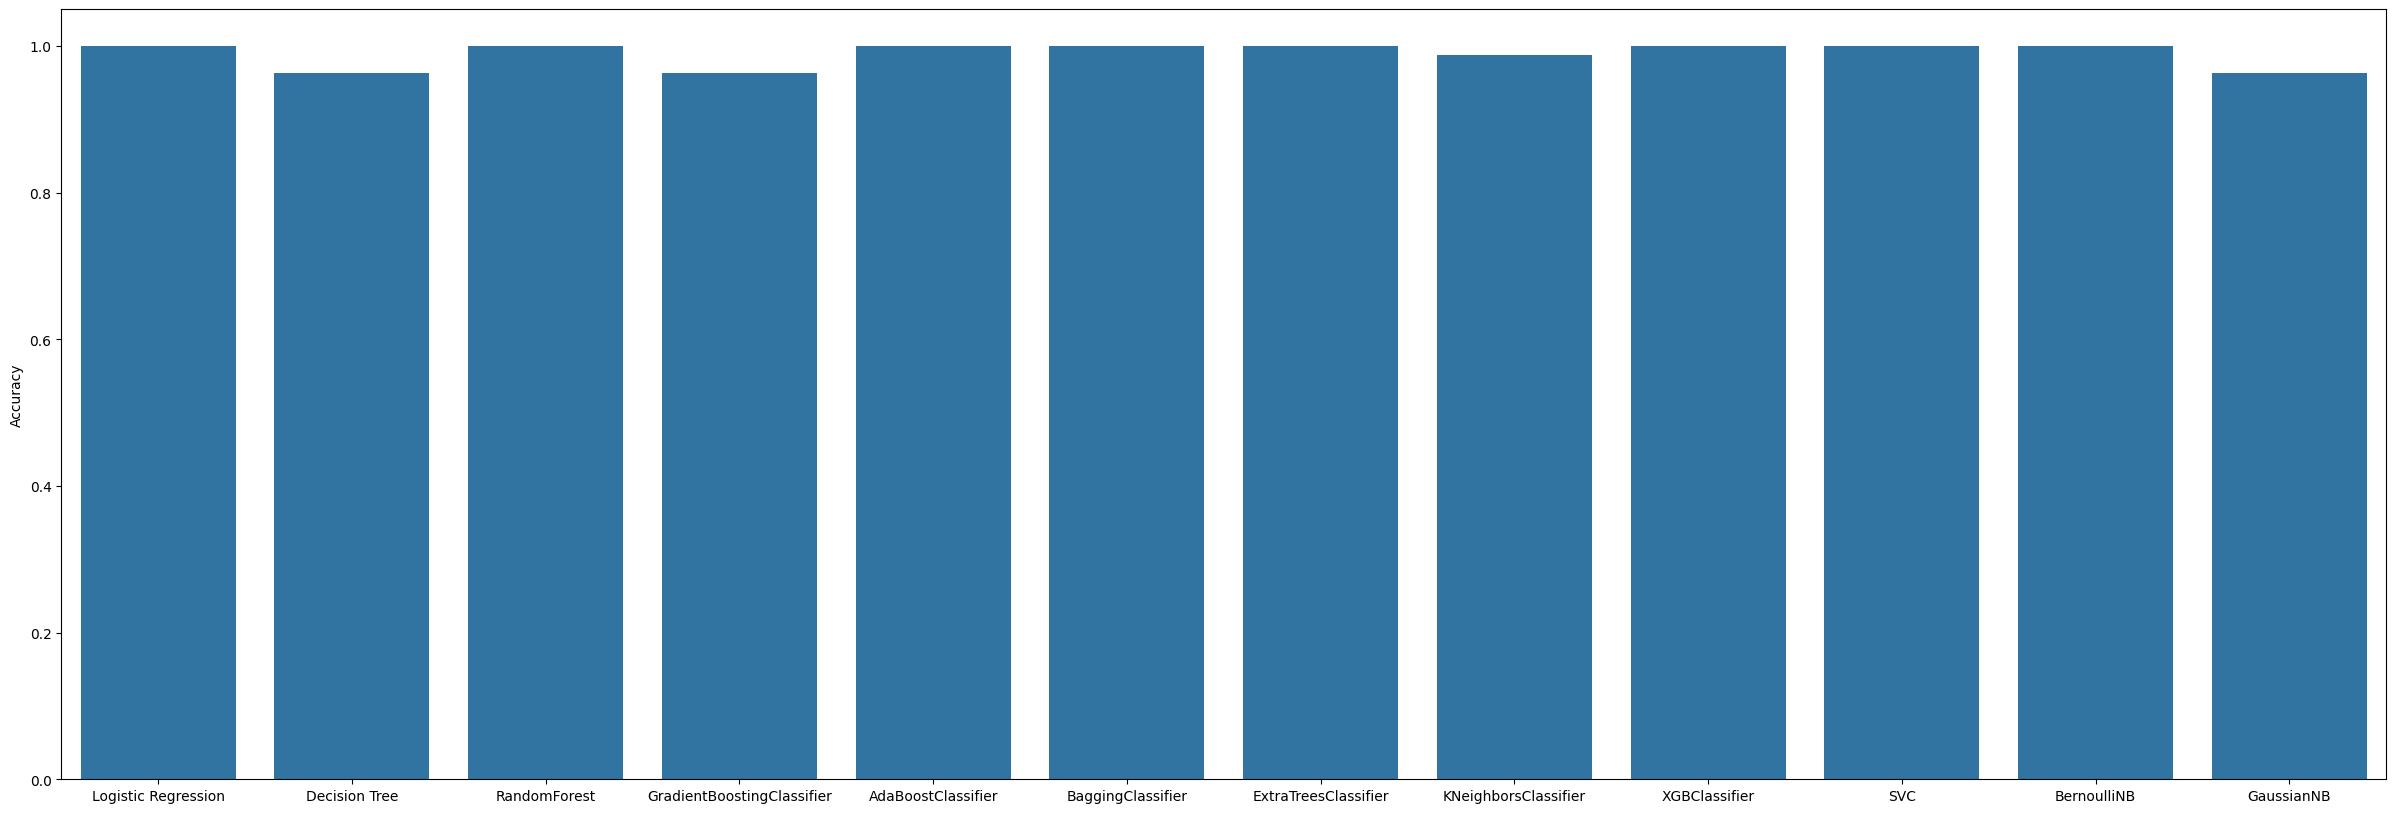

In [111]:
ply.figure(figsize=(30,10))
sns.barplot(x=models,y=report_df['Accuracy'])
ply.show()

### now simillarly check the test accuracy

## This was manual approach automated approach is on google collab (Pycarret)

In [113]:
df_2.to_csv("Cleaned_kidney.csv")

In [ ]:
s